# Lab 12 — Deep Convolutional Neural Networks (CNNs)
### Computer Vision Lab Assignment
---
**Lab Outcomes:**
- Understand the architecture and working of a Deep CNN
- Build and train a CNN using TensorFlow and Keras
- Visualize filters, feature maps, and predictions
- Apply data augmentation and dropout for regularization
- Evaluate CNN performance using classification metrics

> **Note:** Run cells in order. All tasks are self-contained but share the same kernel state.

## 📦 Install & Import Dependencies

In [1]:
# Install required packages (uncomment if running for the first time)
# !pip install tensorflow scikit-learn matplotlib seaborn numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10, mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully ✅")

TensorFlow version: 2.21.0
All libraries imported successfully ✅


---
## ✅ Solved Activities

### Activity 1: Load and Visualize Dataset (CIFAR-10)

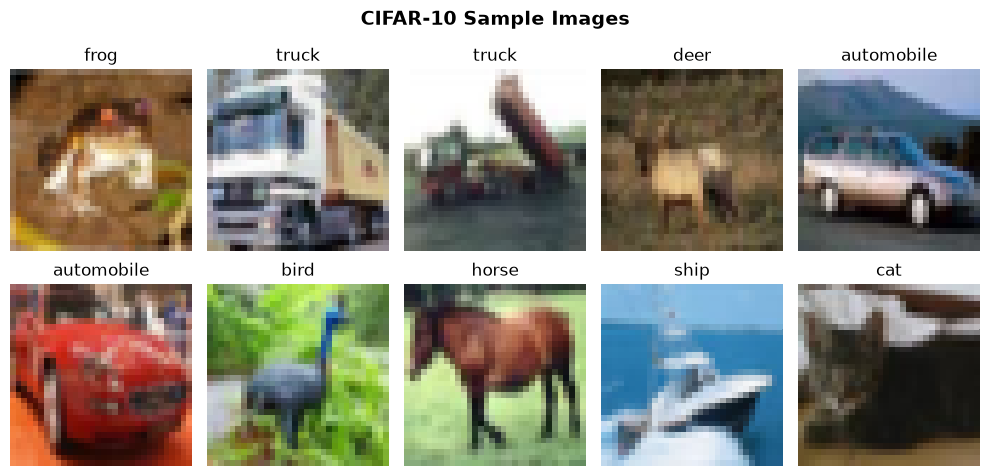

Training samples: 50000, Test samples: 10000
Image shape: (32, 32, 3)


In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Training samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

### Activity 2: Normalize the Data

In [4]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0
print("Pixel values normalized to [0, 1] ✅")
print(f"Min: {x_train.min():.2f}, Max: {x_train.max():.2f}")

Pixel values normalized to [0, 1] ✅
Min: 0.00, Max: 1.00


### Activity 3: Build a Simple CNN Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

### Activity 4: Compile the Model

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("Model compiled with Adam optimizer ✅")

Model compiled with Adam optimizer ✅


### Activity 5: Train the Model

In [7]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3252 - loss: 1.8000 - val_accuracy: 0.4841 - val_loss: 1.4589
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4388 - loss: 1.5197 - val_accuracy: 0.5550 - val_loss: 1.2768
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4865 - loss: 1.4012 - val_accuracy: 0.5828 - val_loss: 1.1610
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5162 - loss: 1.3273 - val_accuracy: 0.6004 - val_loss: 1.1477
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5387 - loss: 1.2698 - val_accuracy: 0.6168 - val_loss: 1.0905
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5640 - loss: 1.2150 - val_accuracy: 0.6226 - val_loss: 1.0759
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5807 - loss: 1.1676 - val_accuracy: 0.6464 - val_loss: 1.0098
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5950 - loss: 1.1281 - 

### Activity 6: Evaluate the Model

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6635 - loss: 0.9648
Test Loss:     0.9648
Test Accuracy: 0.6635


### Activity 7: Plot Accuracy and Loss Curves

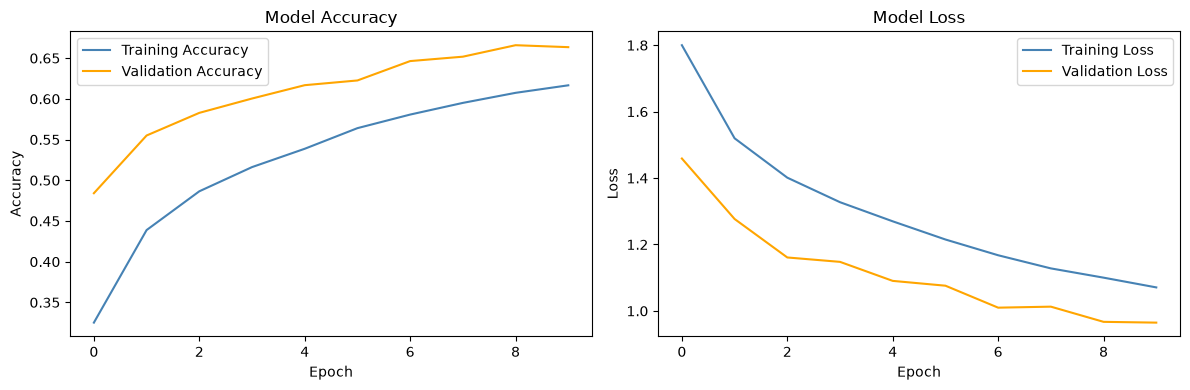

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Training Accuracy',   color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Training Loss',   color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### Activity 8: Data Augmentation

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(x_train)
print("ImageDataGenerator fitted on training data ✅")

ImageDataGenerator fitted on training data ✅


### Activity 9: Retrain Model with Augmented Data

In [11]:
history_aug = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                        epochs=10,
                        validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4615 - loss: 1.5112 - val_accuracy: 0.6115 - val_loss: 1.1280
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4759 - loss: 1.4607 - val_accuracy: 0.6189 - val_loss: 1.0920
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4885 - loss: 1.4336 - val_accuracy: 0.6248 - val_loss: 1.0677
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4948 - loss: 1.4175 - val_accuracy: 0.6470 - val_loss: 1.0182
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4984 - loss: 1.3974 - val_accuracy: 0.6338 - val_loss: 1.0529
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.5094 - loss: 1.3824 - val_accuracy: 0.6107 - val_loss: 1.1040
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5147 - loss: 1.3648 - val_accuracy: 0.6222 - val_loss: 1.0806
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.5135 -

### Activity 10: Predict on New Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


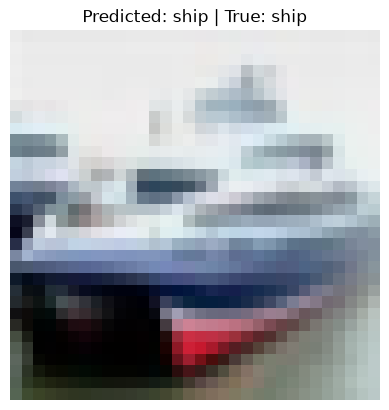

Predicted class: ship


In [12]:
import numpy as np
sample = np.expand_dims(x_test[1], axis=0)
prediction = model.predict(sample)
predicted_label = class_names[np.argmax(prediction)]
true_label      = class_names[y_test[1][0]]

plt.imshow(x_test[1])
plt.title(f"Predicted: {predicted_label} | True: {true_label}")
plt.axis('off')
plt.show()
print(f"Predicted class: {predicted_label}")

---
# 🎯 Graded Tasks

## Task 1 — MNIST CNN (>98% Accuracy)
**Scenario:** A company wants to classify handwritten digits. Load the MNIST dataset and train a CNN to achieve over 98% accuracy.

In [13]:
# ─── Load MNIST ───────────────────────────────────────────────
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_mnist_train, y_mnist_train), (x_mnist_test, y_mnist_test) = mnist.load_data()

# Reshape → (N, 28, 28, 1) and normalize
x_mnist_train = x_mnist_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_mnist_test  = x_mnist_test.reshape(-1, 28, 28, 1).astype('float32')  / 255.0

print(f"Train shape: {x_mnist_train.shape} | Test shape: {x_mnist_test.shape}")

Train shape: (60000, 28, 28, 1) | Test shape: (10000, 28, 28, 1)


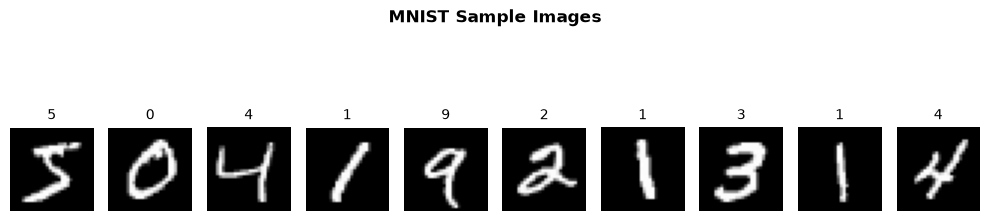

In [14]:
# ─── Visualize a few samples ───────────────────────────────────
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_mnist_train[i].squeeze(), cmap='gray')
    plt.title(str(y_mnist_train[i]), fontsize=10)
    plt.axis('off')
plt.suptitle('MNIST Sample Images', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ─── Build CNN for MNIST ───────────────────────────────────────
mnist_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

mnist_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
mnist_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [16]:
# ─── Train ─────────────────────────────────────────────────────
early_stop_mnist = EarlyStopping(monitor='val_accuracy', patience=3,
                                 restore_best_weights=True, verbose=1)

history_mnist = mnist_model.fit(
    x_mnist_train, y_mnist_train,
    epochs=15, batch_size=64,
    validation_data=(x_mnist_test, y_mnist_test),
    callbacks=[early_stop_mnist]
)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9478 - loss: 0.1705 - val_accuracy: 0.9864 - val_loss: 0.0424
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9810 - loss: 0.0641 - val_accuracy: 0.9899 - val_loss: 0.0287
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9846 - loss: 0.0491 - val_accuracy: 0.9888 - val_loss: 0.0332
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9869 - loss: 0.0421 - val_accuracy: 0.9903 - val_loss: 0.0295
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9893 - loss: 0.0350 - val_accuracy: 0.9926 - val_loss: 0.0215
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9897 - loss: 0.0335 - val_accuracy: 0.9946 - val_loss: 0.0186
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9908 - loss: 0.0291 - val_accuracy: 0.9944 - val_loss: 0.0182
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9912 - loss: 0.0276 - 

In [17]:
# ─── Evaluate ─────────────────────────────────────────────────
loss_m, acc_m = mnist_model.evaluate(x_mnist_test, y_mnist_test, verbose=0)
print(f"✅ MNIST Test Accuracy : {acc_m*100:.2f}%")
print(f"   MNIST Test Loss     : {loss_m:.4f}")

if acc_m >= 0.98:
    print("🎉 Target of 98% accuracy achieved!")
else:
    print("⚠️  Accuracy below 98% — try training for more epochs.")

✅ MNIST Test Accuracy : 99.46%
   MNIST Test Loss     : 0.0186
🎉 Target of 98% accuracy achieved!


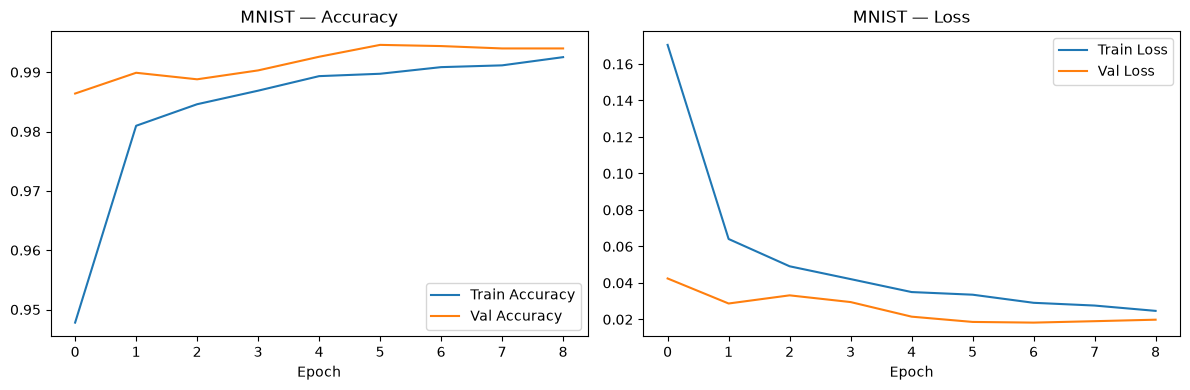

In [18]:
# ─── Plot training curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history_mnist.history[metric],        label=f'Train {metric.capitalize()}')
    ax.plot(history_mnist.history[f'val_{metric}'], label=f'Val {metric.capitalize()}')
    ax.set_title(f'MNIST — {metric.capitalize()}')
    ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.show()

---
## Task 2 — Wildlife Animal Classification (5 Classes from CIFAR-10)
**Scenario:** A wildlife organization has images of 5 animal classes. Simulate using CIFAR-10 animal classes (bird, cat, deer, dog, horse). Train and evaluate performance.

In [19]:
# ─── Load CIFAR-10 fresh and filter 5 animal classes ──────────
(xc, yc), (xc_test, yc_test) = cifar10.load_data()
xc = xc / 255.0;  xc_test = xc_test / 255.0

# CIFAR-10 labels: 2=bird, 3=cat, 4=deer, 5=dog, 7=horse
animal_classes   = [2, 3, 4, 5, 7]
animal_names_map = {2:'bird', 3:'cat', 4:'deer', 5:'dog', 7:'horse'}

def filter_classes(X, Y, class_list):
    """Keep only rows whose label is in class_list; remap labels 0..N-1."""
    label_map  = {old: new for new, old in enumerate(sorted(class_list))}
    mask       = np.isin(Y.flatten(), class_list)
    X_filtered = X[mask]
    Y_filtered = np.array([label_map[y] for y in Y.flatten()[mask]])
    return X_filtered, Y_filtered

x_animal_train, y_animal_train = filter_classes(xc,      yc,      animal_classes)
x_animal_test,  y_animal_test  = filter_classes(xc_test, yc_test, animal_classes)
animal_names = ['bird', 'cat', 'deer', 'dog', 'horse']  # 0-indexed

print(f"Animal Train: {x_animal_train.shape} | Animal Test: {x_animal_test.shape}")

Animal Train: (25000, 32, 32, 3) | Animal Test: (5000, 32, 32, 3)


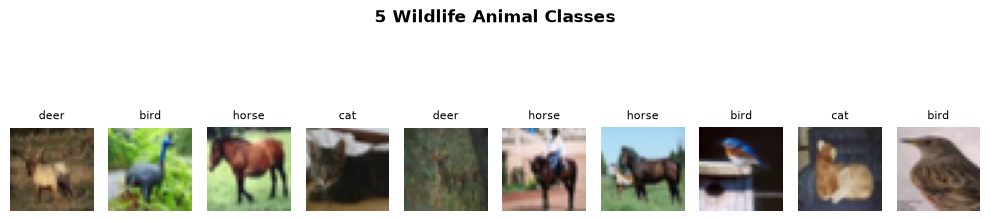

In [20]:
# ─── Visualize samples ────────────────────────────────────────
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_animal_train[i])
    plt.title(animal_names[y_animal_train[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('5 Wildlife Animal Classes', fontweight='bold')
plt.tight_layout(); plt.show()

In [21]:
# ─── Build & Train CNN ────────────────────────────────────────
wildlife_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 animal classes
])

wildlife_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_wildlife = wildlife_model.fit(
    x_animal_train, y_animal_train,
    epochs=20, batch_size=64,
    validation_data=(x_animal_test, y_animal_test),
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=4,
                             restore_best_weights=True, verbose=1)]
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3639 - loss: 1.4934 - val_accuracy: 0.3666 - val_loss: 2.0691
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4462 - loss: 1.3045 - val_accuracy: 0.5248 - val_loss: 1.1336
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5044 - loss: 1.2040 - val_accuracy: 0.5092 - val_loss: 1.2172
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5369 - loss: 1.1375 - val_accuracy: 0.5626 - val_loss: 1.0928
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5682 - loss: 1.0736 - val_accuracy: 0.4454 - val_loss: 1.9459
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5972 - loss: 1.0252 - val_accuracy: 0.5600 - val_loss: 1.1690
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6181 - loss: 0.9770 - val_accuracy: 0.6558 - val_loss: 0.9055
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6359 - loss: 0.9388 - val_acc

In [22]:
# ─── Evaluate & Report ────────────────────────────────────────
loss_w, acc_w = wildlife_model.evaluate(x_animal_test, y_animal_test, verbose=0)
print(f"Wildlife Model Test Accuracy: {acc_w*100:.2f}%")

y_pred_w = np.argmax(wildlife_model.predict(x_animal_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_animal_test, y_pred_w, target_names=animal_names))

Wildlife Model Test Accuracy: 73.28%
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:
              precision    recall  f1-score   support

        bird       0.79      0.71      0.75      1000
         cat       0.66      0.61      0.63      1000
        deer       0.70      0.83      0.76      1000
         dog       0.70      0.70      0.70      1000
       horse       0.83      0.82      0.82      1000

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



---
## Task 3 — Lightweight CNN for Mobile (Fewer Parameters)
**Scenario:** Your team is working on real-time object classification on mobile. Build a smaller CNN architecture with fewer parameters.

In [23]:
# ─── MobileNet-inspired lightweight CNN ───────────────────────
# Uses Depthwise Separable Convolutions via SeparableConv2D
from tensorflow.keras.layers import SeparableConv2D, GlobalAveragePooling2D

(x_c10, y_c10), (x_c10t, y_c10t) = cifar10.load_data()
x_c10  = x_c10  / 255.0
x_c10t = x_c10t / 255.0

def build_lightweight_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        # Standard conv for first layer (cheaper since input channels=3)
        Conv2D(16, (3,3), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D((2,2)),

        # Depthwise Separable Convolutions — drastically fewer parameters
        SeparableConv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        SeparableConv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        # Global Average Pooling replaces Flatten + Dense (saves parameters)
        GlobalAveragePooling2D(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model

# ─── Compare parameter counts ────────────────────────────────
standard_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(), Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(), Flatten(),
    Dense(64, activation='relu'), Dense(10, activation='softmax')
])

light_cnn = build_lightweight_cnn()

std_params   = standard_cnn.count_params()
light_params = light_cnn.count_params()

print(f"Standard CNN Parameters  : {std_params:,}")
print(f"Lightweight CNN Parameters: {light_params:,}")
print(f"Parameter Reduction      : {(1 - light_params/std_params)*100:.1f}%")
light_cnn.summary()

Standard CNN Parameters  : 167,562
Lightweight CNN Parameters: 8,346
Parameter Reduction      : 95.0%


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 16, 16, 32)     │           688 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 8, 8, 64)       │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,346 (32.60 KB)

 Trainable params: 8,346 (32.60 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# ─── Train Lightweight CNN ────────────────────────────────────
light_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_light = light_cnn.fit(
    x_c10, y_c10,
    epochs=15, batch_size=64,
    validation_data=(x_c10t, y_c10t),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True, verbose=1)]
)

_, acc_light = light_cnn.evaluate(x_c10t, y_c10t, verbose=0)
print(f"\n✅ Lightweight CNN Test Accuracy: {acc_light*100:.2f}%")
print(f"   Model size suitable for mobile deployment!")

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2138 - loss: 2.0566 - val_accuracy: 0.2861 - val_loss: 1.8768
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2993 - loss: 1.8166 - val_accuracy: 0.3464 - val_loss: 1.6949
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3460 - loss: 1.7148 - val_accuracy: 0.3836 - val_loss: 1.6295
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3695 - loss: 1.6687 - val_accuracy: 0.3934 - val_loss: 1.5985
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3863 - loss: 1.6324 - val_accuracy: 0.4261 - val_loss: 1.5364
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4033 - loss: 1.5973 - val_accuracy: 0.4393 - val_loss: 1.5115
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4198 - loss: 1.5625 - val_accuracy: 0.4576 - val_loss: 1.4648
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4316 - loss: 1.5345 - val_accuracy: 0.

---
## Task 4 — Dropout & Data Augmentation: Before vs After Comparison
**Scenario:** Add dropout and data augmentation to prevent overfitting in your CIFAR-10 model. Show before and after accuracy comparisons.

In [25]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

# ─── Load & prepare data ──────────────────────────────────────────────────────
(x_t4_np, y_t4_np), (x_t4v_np, y_t4v_np) = cifar10.load_data()

# Explicitly convert to TensorFlow tensors with correct dtypes, then process
x_t4  = tf.convert_to_tensor(x_t4_np, dtype=tf.float32) / 255.0
x_t4v = tf.convert_to_tensor(x_t4v_np, dtype=tf.float32) / 255.0
y_t4  = tf.convert_to_tensor(y_t4_np, dtype=tf.int32)
y_t4v = tf.convert_to_tensor(y_t4v_np, dtype=tf.int32)

# Squeeze y_t4 and y_t4v after conversion to tensor if they are still (N, 1)
if len(y_t4.shape) == 2 and y_t4.shape[1] == 1:
    y_t4 = tf.squeeze(y_t4)
if len(y_t4v.shape) == 2 and y_t4v.shape[1] == 1:
    y_t4v = tf.squeeze(y_t4v)


# ─── Augmentation fn: input is a BATCH [batch,32,32,3] ───────────────────────
def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.1)
    # ✅ FIX: 4 padding pairs for rank-4 tensor [batch, H, W, C]
    x = tf.pad(x, [[0,0], [4,4], [4,4], [0,0]])
    x = tf.image.random_crop(x, [tf.shape(x)[0], 32, 32, 3])
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

BATCH  = 64
EPOCHS = 15

# Create tf.data.Dataset for both baseline and regularized models
base_train_ds = (tf.data.Dataset.from_tensor_slices((x_t4, y_t4))
                 .shuffle(50000)
                 .batch(BATCH)
                 .prefetch(tf.data.AUTOTUNE))

base_val_ds = (tf.data.Dataset.from_tensor_slices((x_t4v, y_t4v))
               .batch(BATCH)
               .prefetch(tf.data.AUTOTUNE))

train_ds = (tf.data.Dataset.from_tensor_slices((x_t4, y_t4))
            .shuffle(50000)
            .batch(BATCH)
            .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((x_t4v, y_t4v))
          .batch(BATCH)
          .prefetch(tf.data.AUTOTUNE))

# ─── Models ───────────────────────────────────────────────────────────────────
def build_base_model():
    m = Sequential([
        Input(shape=(32,32,3)), # Explicitly define input layer
        Conv2D(32,(3,3), activation='relu', padding='same'),
        MaxPooling2D(),
        Conv2D(64,(3,3), activation='relu', padding='same'),
        MaxPooling2D(),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
    return m

def build_regularized_model():
    m = Sequential([
        Input(shape=(32,32,3)), # Explicitly define input layer
        Conv2D(32,(3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(), Dropout(0.25),
        Conv2D(64,(3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(), Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.5),
        Dense(10,  activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
    return m

# ─── Train ────────────────────────────────────────────────────────────────────
print("Training baseline model (no regularization)...")
base_model = build_base_model()
hist_base  = base_model.fit(base_train_ds,
                             epochs=EPOCHS,
                             validation_data=base_val_ds, verbose=1)

print("\nTraining regularized model (Dropout + BatchNorm + Augmentation)...")
reg_model = build_regularized_model()
hist_reg  = reg_model.fit(train_ds,
                           epochs=EPOCHS,
                           validation_data=val_ds, verbose=1)

# ─── Evaluate ─────────────────────────────────────────────────────────────────
_, acc_base = base_model.evaluate(base_val_ds, verbose=0)
_, acc_reg  = reg_model.evaluate(val_ds,         verbose=0)

print(f"\n📊 Results:")
print(f"   Baseline    Test Accuracy : {acc_base*100:.2f}%")
print(f"   Regularized Test Accuracy : {acc_reg*100:.2f}%")
print(f"   Improvement               : +{(acc_reg - acc_base)*100:.2f}%")

Training baseline model (no regularization)...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4689 - loss: 1.4809 - val_accuracy: 0.5653 - val_loss: 1.2182
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6125 - loss: 1.1086 - val_accuracy: 0.6316 - val_loss: 1.0611
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6630 - loss: 0.9697 - val_accuracy: 0.6530 - val_loss: 0.9942
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6923 - loss: 0.8873 - val_accuracy: 0.6649 - val_loss: 0.9559
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7144 - loss: 0.8219 - val_accuracy: 0.6689 - val_loss: 0.9420
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7307 - loss: 0.7741 - val_accuracy: 0.6995 - val_loss: 0.8733
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7465 - loss: 0.7302 - val_accuracy: 0.7006 - val_loss: 0.8851
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc

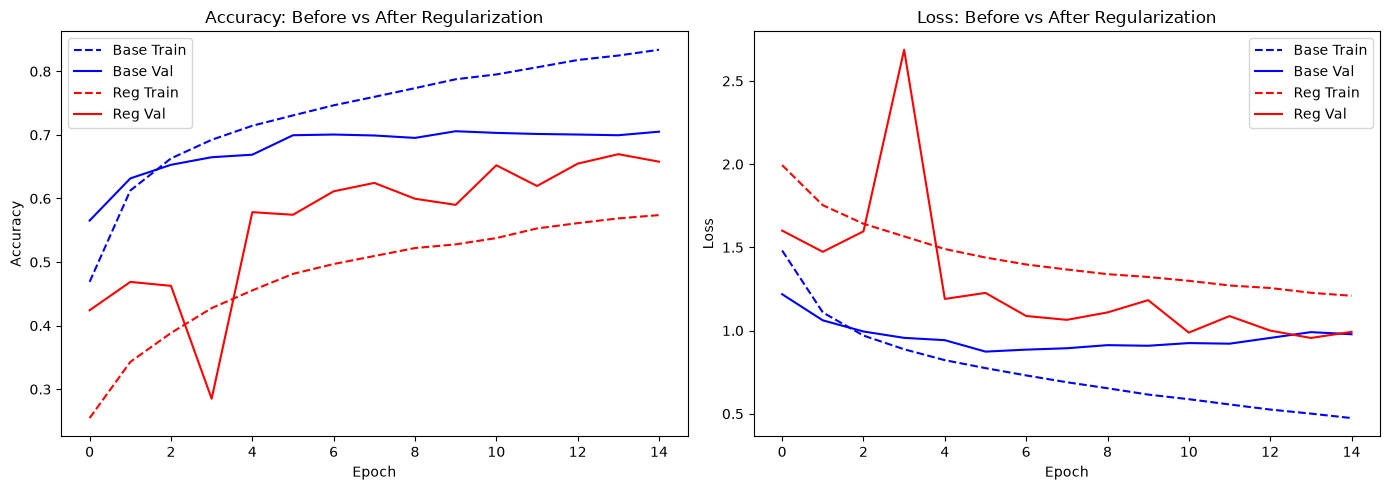

🔍 Observation: The gap between train/val curves shrinks with regularization — less overfitting!


In [26]:
import matplotlib.pyplot as plt

# ─── Visualize Overfitting: Before vs After ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(hist_base.history['accuracy'],     'b--', label='Base Train')
axes[0].plot(hist_base.history['val_accuracy'], 'b-',  label='Base Val')
axes[0].plot(hist_reg.history['accuracy'],      'r--', label='Reg Train')
axes[0].plot(hist_reg.history['val_accuracy'],  'r-',  label='Reg Val')
axes[0].set_title('Accuracy: Before vs After Regularization')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(hist_base.history['loss'],     'b--', label='Base Train')
axes[1].plot(hist_base.history['val_loss'], 'b-',  label='Base Val')
axes[1].plot(hist_reg.history['loss'],      'r--', label='Reg Train')
axes[1].plot(hist_reg.history['val_loss'],  'r-',  label='Reg Val')
axes[1].set_title('Loss: Before vs After Regularization')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout(); plt.show()
print("🔍 Observation: The gap between train/val curves shrinks with regularization — less overfitting!")

---
## Task 5 — Visualize Feature Maps After First Conv Layer
**Scenario:** Visualize the feature maps after the first convolution layer using any sample image.

In [27]:
# ─── Build a fresh CNN just for visualization ─────────────────
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Load CIFAR-10
(x_t5, y_t5), (x_t5v, y_t5v) = cifar10.load_data()

# Normalize images
x_t5 = x_t5.astype("float32") / 255.0
x_t5v = x_t5v.astype("float32") / 255.0

# Convert labels to 1-D integer arrays
y_t5 = y_t5.squeeze().astype("int32")
y_t5v = y_t5v.squeeze().astype("int32")

# Build CNN
vis_model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation='relu',
           padding='same', name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),

    Conv2D(64, (3, 3), activation='relu',
           padding='same', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
vis_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
vis_model.fit(
    x_t5,
    y_t5,
    epochs=5,
    batch_size=64,
    validation_data=(x_t5v, y_t5v),
    verbose=1
)

print("Model trained. Now extracting feature maps...")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4549 - loss: 1.5262 - val_accuracy: 0.5686 - val_loss: 1.2139
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6011 - loss: 1.1400 - val_accuracy: 0.6192 - val_loss: 1.0895
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6472 - loss: 1.0070 - val_accuracy: 0.6339 - val_loss: 1.0529
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6777 - loss: 0.9278 - val_accuracy: 0.6714 - val_loss: 0.9524
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7035 - loss: 0.8572 - val_accuracy: 0.6753 - val_loss: 0.9368
Model trained. Now extracting feature maps...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


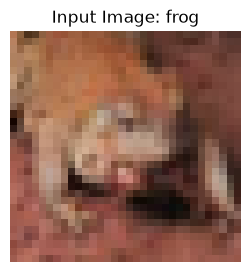

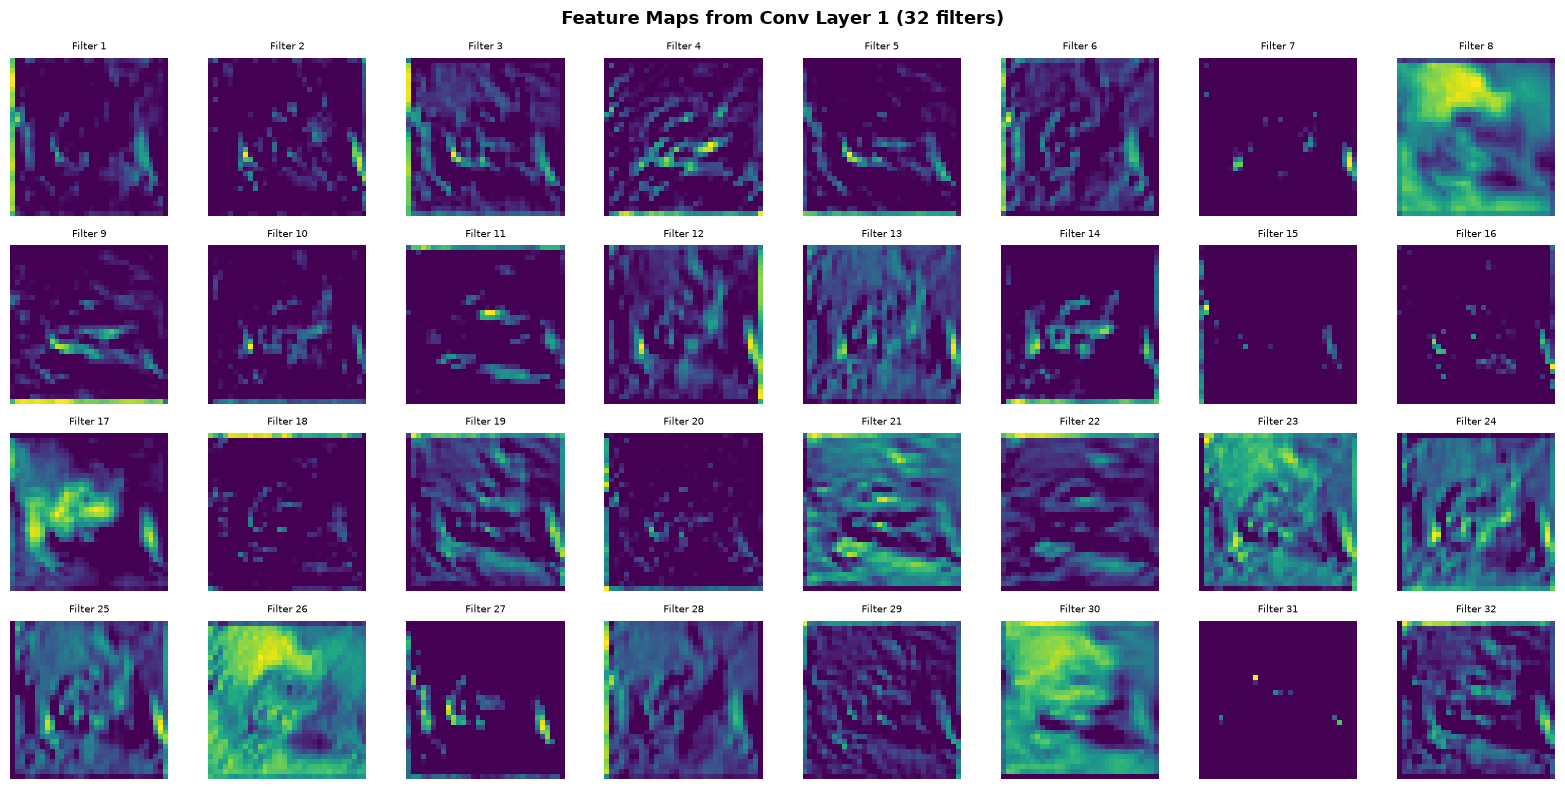

Feature map shape: (1, 32, 32, 32)
Each feature map highlights different spatial patterns (edges, textures, etc.)


In [28]:
# ─── Create Feature Map Extractor ────────────────────────────
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Make sure the model has been called
_ = vis_model(x_t5v[:1])

# Extract output of first convolutional layer
feature_map_model = Model(
    inputs=vis_model.inputs,
    outputs=vis_model.get_layer('conv1').output
)

# Pick a sample image
sample_idx = 5
sample_img = x_t5v[sample_idx]
sample_input = np.expand_dims(sample_img, axis=0)

# Get feature maps
feature_maps = feature_map_model.predict(sample_input)

# ─── Visualize original image ────────────────────────────────
plt.figure(figsize=(3, 3))
plt.imshow(sample_img)
plt.title(f"Input Image: {class_names[y_t5v[sample_idx]]}")
plt.axis('off')
plt.show()

# ─── Visualize first 16 feature maps ─────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
        ax.set_title(f'Filter {i+1}', fontsize=7)

    ax.axis('off')

plt.suptitle(
    'Feature Maps from Conv Layer 1 (32 filters)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("Feature map shape:", feature_maps.shape)
print("Each feature map highlights different spatial patterns (edges, textures, etc.)")

---
## Task 6 — Save & Load Model for Inference
**Scenario:** Save your trained model and load it again for inference on unseen data.

In [29]:
# ─── Save the model ──────────────────────────────────────────
MODEL_PATH = 'cifar10_cnn_model.h5'
vis_model.save(MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")
print(f"   File size: {__import__('os').path.getsize(MODEL_PATH) / 1024:.1f} KB")

✅ Model saved to: cifar10_cnn_model.h5
   File size: 3345.9 KB


In [30]:
# ─── Load the model back ──────────────────────────────────────
from tensorflow.keras.models import load_model

loaded_model = load_model(MODEL_PATH)
print("✅ Model loaded successfully!")
loaded_model.summary()

✅ Model loaded successfully!


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,252 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

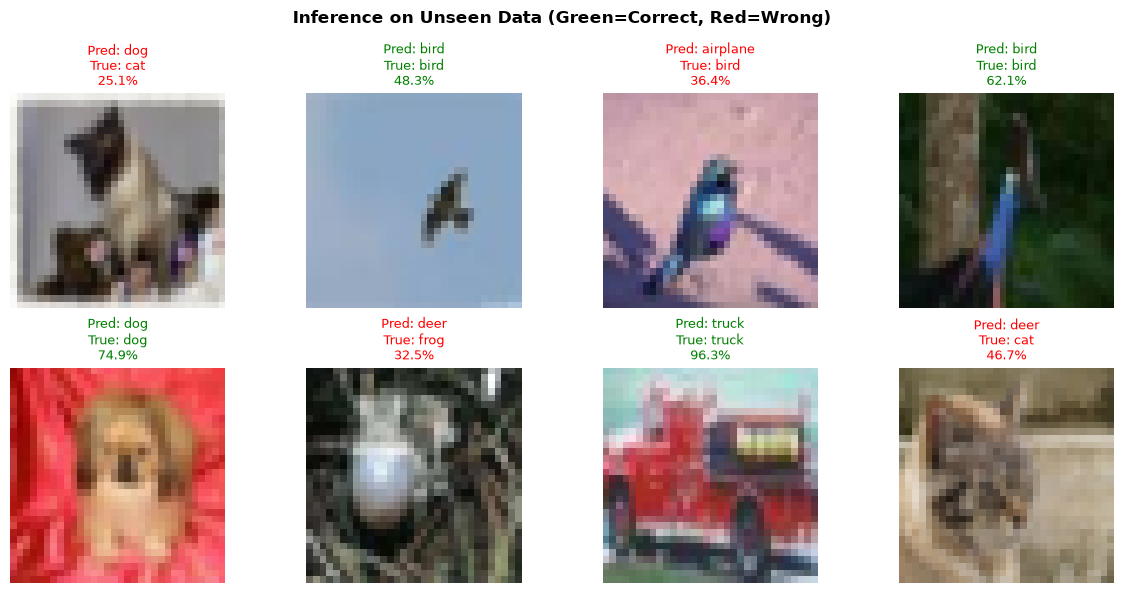

Model saved and reloaded successfully for inference ✅


In [31]:
# ─── Inference on unseen test images ─────────────────────────

n_samples = 8
indices = np.random.choice(len(x_t5v), n_samples, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, idx in zip(axes.flat, indices):

    img = x_t5v[idx]

    pred = loaded_model.predict(
        np.expand_dims(img, 0),
        verbose=0
    )

    pred_class = class_names[np.argmax(pred)]

    # FIXED: y_t5v is already squeezed to 1-D
    true_class = class_names[y_t5v[idx]]

    confidence = np.max(pred) * 100

    ax.imshow(img)

    color = 'green' if pred_class == true_class else 'red'

    ax.set_title(
        f"Pred: {pred_class}\n"
        f"True: {true_class}\n"
        f"{confidence:.1f}%",
        color=color,
        fontsize=9
    )

    ax.axis('off')

plt.suptitle(
    'Inference on Unseen Data (Green=Correct, Red=Wrong)',
    fontweight='bold',
    fontsize=12
)

plt.tight_layout()
plt.show()

print("Model saved and reloaded successfully for inference ✅")

---
## Task 7 — Grayscale vs RGB CIFAR-10 Comparison
**Scenario:** Train the CNN on grayscale versions of CIFAR-10. Compare results with RGB input.

RGB   shape: (50000, 32, 32, 3)
Gray  shape: (50000, 32, 32, 1)


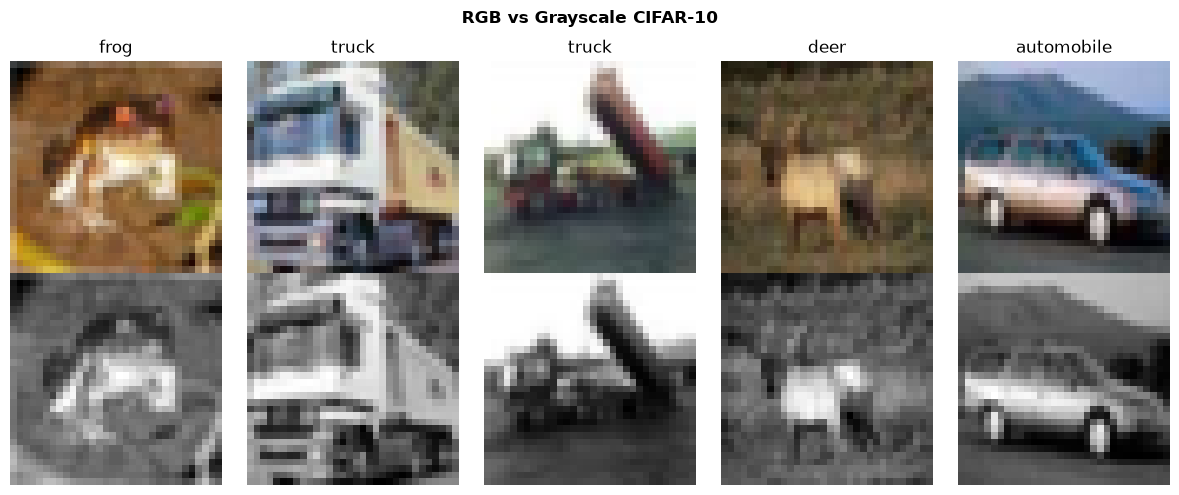

In [32]:
# ─── Load and prepare data ────────────────────────────────────
(x_rgb, y_rgb), (x_rgb_test, y_rgb_test) = cifar10.load_data()
x_rgb      = x_rgb      / 255.0
x_rgb_test = x_rgb_test / 255.0

# Convert to grayscale: luminance formula
x_gray      = np.dot(x_rgb,      [0.2989, 0.5870, 0.1140])[..., np.newaxis]
x_gray_test = np.dot(x_rgb_test, [0.2989, 0.5870, 0.1140])[..., np.newaxis]

print(f"RGB   shape: {x_rgb.shape}")
print(f"Gray  shape: {x_gray.shape}")

# Visualize side-by-side
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0][i].imshow(x_rgb[i]);                      axes[0][i].set_title(class_names[y_rgb[i][0]]); axes[0][i].axis('off')
    axes[1][i].imshow(x_gray[i].squeeze(), cmap='gray'); axes[1][i].axis('off')
axes[0][0].set_ylabel('RGB',  rotation=0, labelpad=30, fontsize=12)
axes[1][0].set_ylabel('Gray', rotation=0, labelpad=30, fontsize=12)
plt.suptitle('RGB vs Grayscale CIFAR-10', fontweight='bold'); plt.tight_layout(); plt.show()

In [33]:
# ─── Make sure data has correct NumPy dtypes ─────────────────

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input

# Convert images to float32
x_rgb = np.asarray(x_rgb, dtype=np.float32)
x_rgb_test = np.asarray(x_rgb_test, dtype=np.float32)

x_gray = np.asarray(x_gray, dtype=np.float32)
x_gray_test = np.asarray(x_gray_test, dtype=np.float32)

# Convert labels to int32 and make them 1-D
y_rgb = np.asarray(y_rgb, dtype=np.int32).squeeze()
y_rgb_test = np.asarray(y_rgb_test, dtype=np.int32).squeeze()


# ─── Build same architecture for both ────────────────────────

def build_cnn_for_channels(channels):

    m = Sequential([
        Input(shape=(32, 32, channels)),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(),
        Dropout(0.25),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    m.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return m


EPOCHS_T7 = 10


# ─── Train RGB model ─────────────────────────────────────────

print("Training RGB model...")

rgb_model = build_cnn_for_channels(3)

hist_rgb = rgb_model.fit(
    x_rgb,
    y_rgb,
    epochs=EPOCHS_T7,
    batch_size=64,
    validation_data=(x_rgb_test, y_rgb_test),
    verbose=1
)


# ─── Train Grayscale model ──────────────────────────────────

print("Training Grayscale model...")

gray_model = build_cnn_for_channels(1)

hist_gray = gray_model.fit(
    x_gray,
    y_rgb,
    epochs=EPOCHS_T7,
    batch_size=64,
    validation_data=(x_gray_test, y_rgb_test),
    verbose=1
)


# ─── Evaluate both models ────────────────────────────────────

_, acc_rgb = rgb_model.evaluate(
    x_rgb_test,
    y_rgb_test,
    verbose=0
)

_, acc_gray = gray_model.evaluate(
    x_gray_test,
    y_rgb_test,
    verbose=0
)


print("\n📊 Comparison:")
print(f"   RGB   Test Accuracy: {acc_rgb * 100:.2f}%")
print(f"   Gray  Test Accuracy: {acc_gray * 100:.2f}%")
print(f"   Difference (RGB - Gray): {(acc_rgb - acc_gray) * 100:.2f}%")

Training RGB model...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3545 - loss: 1.7603 - val_accuracy: 0.5153 - val_loss: 1.3665
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4822 - loss: 1.4347 - val_accuracy: 0.5795 - val_loss: 1.1962
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5344 - loss: 1.3034 - val_accuracy: 0.6022 - val_loss: 1.1197
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5667 - loss: 1.2188 - val_accuracy: 0.6320 - val_loss: 1.0531
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5866 - loss: 1.1600 - val_accuracy: 0.6601 - val_loss: 0.9786
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6021 - loss: 1.1166 - val_accuracy: 0.6684 - val_loss: 0.9549
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6166 - loss: 1.0829 - val_accuracy: 0.6710 - val_loss: 0.9551
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6298 - l

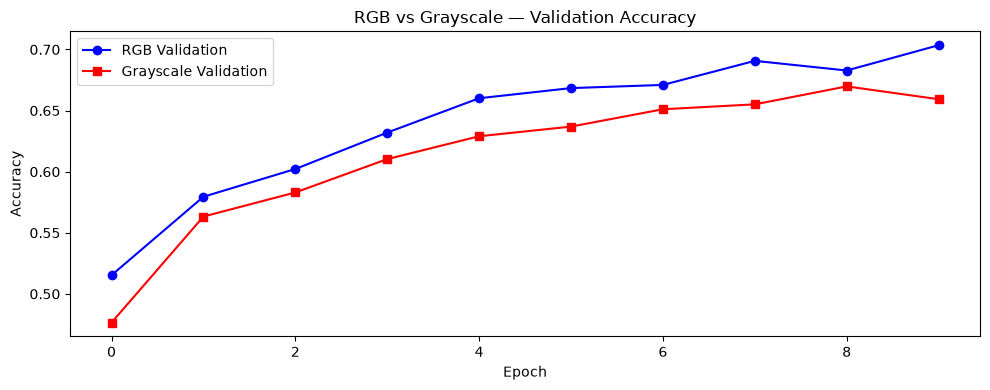

In [34]:
# ─── Plot comparison curves ───────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(hist_rgb.history['val_accuracy'],  'b-o', label='RGB Validation')
plt.plot(hist_gray.history['val_accuracy'], 'r-s', label='Grayscale Validation')
plt.title('RGB vs Grayscale — Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

---
## Task 8 — Compare Optimizers: Adam vs SGD vs RMSprop
**Scenario:** Use different optimizers (SGD, RMSprop) and compare model performance.

In [35]:
# ─── Load Data ───────────────────────────────────────────────
(x_t8, y_t8), (x_t8v, y_t8v) = cifar10.load_data()
x_t8  = x_t8  / 255.0
x_t8v = x_t8v / 255.0

def build_opt_model():
    """Same architecture — only optimizer changes."""
    return Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(), Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.5),
        Dense(10, activation='softmax')
    ])

optimizers = {
    'Adam'    : tf.keras.optimizers.Adam(learning_rate=0.001),
    'SGD'     : tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop' : tf.keras.optimizers.RMSprop(learning_rate=0.001)
}

histories_opt = {}
results_opt   = {}
EPOCHS_T8 = 10

for opt_name, optimizer in optimizers.items():
    print(f"Training with {opt_name}...")
    m = build_opt_model()
    m.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    h = m.fit(x_t8, y_t8, epochs=EPOCHS_T8, batch_size=64,
              validation_data=(x_t8v, y_t8v), verbose=0)
    _, acc = m.evaluate(x_t8v, y_t8v, verbose=0)
    histories_opt[opt_name] = h
    results_opt[opt_name]   = acc
    print(f"  → Test Accuracy: {acc*100:.2f}%")

print("\n📊 Optimizer Comparison Summary:")
for opt_name, acc in results_opt.items():
    bar = '█' * int(acc * 50)
    print(f"  {opt_name:<10}: {acc*100:.2f}% {bar}")

Training with Adam...
  → Test Accuracy: 67.73%
Training with SGD...
  → Test Accuracy: 69.42%
Training with RMSprop...
  → Test Accuracy: 66.36%

📊 Optimizer Comparison Summary:
  Adam      : 67.73% █████████████████████████████████
  SGD       : 69.42% ██████████████████████████████████
  RMSprop   : 66.36% █████████████████████████████████


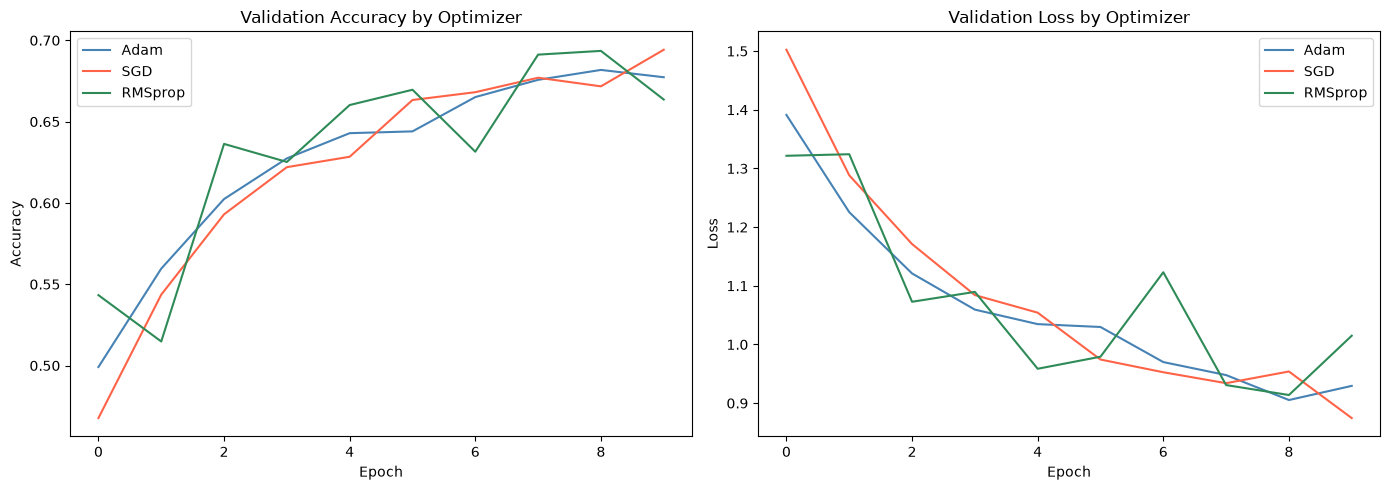

💡 Adam typically converges fastest; SGD with momentum can generalize well with enough epochs.


In [36]:
# ─── Plot Optimizer Comparison ────────────────────────────────
colors = {'Adam': 'steelblue', 'SGD': 'tomato', 'RMSprop': 'seagreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for opt_name, h in histories_opt.items():
    axes[0].plot(h.history['val_accuracy'],  label=opt_name, color=colors[opt_name])
    axes[1].plot(h.history['val_loss'],      label=opt_name, color=colors[opt_name])

axes[0].set_title('Validation Accuracy by Optimizer'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].set_title('Validation Loss by Optimizer');     axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss');     axes[1].legend()
plt.tight_layout(); plt.show()

print("💡 Adam typically converges fastest; SGD with momentum can generalize well with enough epochs.")

---
## Task 9 — Early Stopping
**Scenario:** Implement early stopping during training and explain its benefit.

In [37]:
# ─── Data ────────────────────────────────────────────────────
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Load CIFAR-10
(x_t9, y_t9), (x_t9v, y_t9v) = cifar10.load_data()

# Convert images to numeric float32 and normalize
x_t9 = x_t9.astype(np.float32) / 255.0
x_t9v = x_t9v.astype(np.float32) / 255.0

# Convert labels to numeric int32 and remove extra dimension
y_t9 = y_t9.astype(np.int32).squeeze()
y_t9v = y_t9v.astype(np.int32).squeeze()


# ─── Build CNN ───────────────────────────────────────────────
def build_model_t9():

    m = Sequential([
        Input(shape=(32, 32, 3)),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.25),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    m.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return m


# ─── Early Stopping ──────────────────────────────────────────
MAX_EPOCHS = 50

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1
)


# ─── Train ───────────────────────────────────────────────────
print(
    f"Training with max {MAX_EPOCHS} epochs — "
    "EarlyStopping will halt training automatically..."
)

es_model = build_model_t9()

hist_es = es_model.fit(
    x_t9,
    y_t9,
    epochs=MAX_EPOCHS,
    batch_size=64,
    validation_data=(x_t9v, y_t9v),
    callbacks=[early_stop],
    verbose=1
)


# ─── Evaluate ────────────────────────────────────────────────
actual_epochs = len(hist_es.history['loss'])

_, acc_es = es_model.evaluate(
    x_t9v,
    y_t9v,
    verbose=0
)

print(f"\nEarly Stopping finished at epoch {actual_epochs}/{MAX_EPOCHS}")
print(f"Saved {MAX_EPOCHS - actual_epochs} unnecessary epochs of training!")
print(f"Final Test Accuracy: {acc_es * 100:.2f}%")

Training with max 50 epochs — EarlyStopping will halt training automatically...
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.3188 - loss: 1.8736 - val_accuracy: 0.4838 - val_loss: 1.4469
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.4456 - loss: 1.5157 - val_accuracy: 0.5524 - val_loss: 1.2392
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5135 - loss: 1.3550 - val_accuracy: 0.6055 - val_loss: 1.1247
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5607 - loss: 1.2429 - val_accuracy: 0.6084 - val_loss: 1.1532
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5902 - loss: 1.1676 - val_accuracy: 0.6513 - val_loss: 1.0063
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.6096 - loss: 1.1110 - val_accuracy: 0.6100 - val_loss: 1.1573
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6264 - loss: 1.0701 - val_accuracy: 0.6850 - val_loss: 0.9349
Epoch 8/50

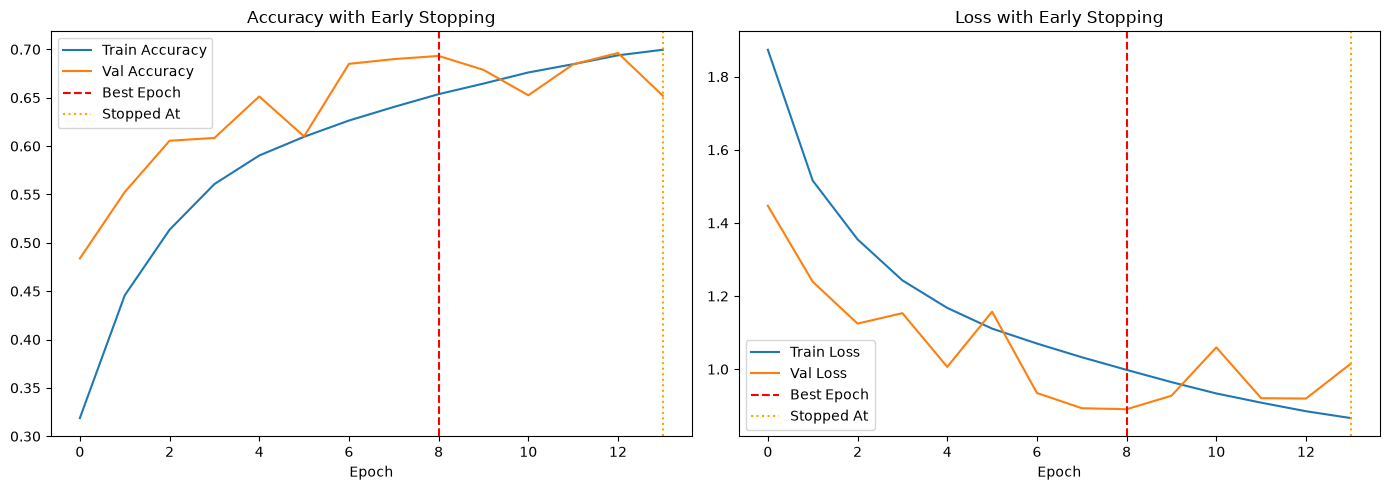


📚 Early Stopping Benefits:
  1. Prevents overfitting by stopping before the model memorizes training data
  2. Saves computation time — no wasted training epochs
  3. restore_best_weights=True ensures best model is returned, not last
  4. Acts as implicit regularization without changing architecture



In [38]:
# ─── Plot with Early Stop annotation ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(hist_es.history[metric],         label=f'Train {metric.capitalize()}')
    ax.plot(hist_es.history[f'val_{metric}'], label=f'Val {metric.capitalize()}')
    ax.axvline(x=actual_epochs - early_stop.patience - 1,
               color='red', linestyle='--', label='Best Epoch')
    ax.axvline(x=actual_epochs - 1,
               color='orange', linestyle=':', label='Stopped At')
    ax.set_title(f'{metric.capitalize()} with Early Stopping')
    ax.set_xlabel('Epoch'); ax.legend()

plt.tight_layout(); plt.show()

print("""
📚 Early Stopping Benefits:
  1. Prevents overfitting by stopping before the model memorizes training data
  2. Saves computation time — no wasted training epochs
  3. restore_best_weights=True ensures best model is returned, not last
  4. Acts as implicit regularization without changing architecture
""")

---
## Task 10 — Evaluation Metrics: Confusion Matrix, Precision, Recall
**Scenario:** Using model evaluation metrics (Confusion Matrix, Precision, Recall), assess your trained model on CIFAR-10.

In [39]:
# ─── Task 10: Model Evaluation ─────────────────────────────

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Flatten, Dense
)
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Load CIFAR-10
(x_t10, y_t10), (x_t10v, y_t10v) = cifar10.load_data()

# Explicitly convert data to numeric types
x_t10 = np.asarray(x_t10, dtype=np.float32) / 255.0
x_t10v = np.asarray(x_t10v, dtype=np.float32) / 255.0

y_t10 = np.asarray(y_t10, dtype=np.int32).squeeze()
y_t10v = np.asarray(y_t10v, dtype=np.int32).squeeze()

# Build model
eval_model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Compile
eval_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop_t10 = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# Train
history_t10 = eval_model.fit(
    x_t10,
    y_t10,
    epochs=15,
    batch_size=64,
    validation_data=(x_t10v, y_t10v),
    callbacks=[early_stop_t10],
    verbose=1
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.3805 - loss: 1.7307 - val_accuracy: 0.4931 - val_loss: 1.4491
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5077 - loss: 1.3707 - val_accuracy: 0.5799 - val_loss: 1.1555
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5697 - loss: 1.2087 - val_accuracy: 0.5786 - val_loss: 1.2763
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6113 - loss: 1.1028 - val_accuracy: 0.6151 - val_loss: 1.1320
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.6437 - loss: 1.0213 - val_accuracy: 0.6778 - val_loss: 0.9331
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.6617 - loss: 0.9717 - val_accuracy: 0.5711 - val_loss: 1.3447
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6813 - loss: 0.9213 - val_accuracy: 0.7100 - val_loss: 0.8354
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6943 - loss: 0.8858 - 

In [40]:
# ─── Predictions ─────────────────────────────────────────────
y_pred_probs = eval_model.predict(x_t10v)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_t10v.flatten()

# ─── Overall accuracy ────────────────────────────────────────
_, test_acc_final = eval_model.evaluate(x_t10v, y_t10v, verbose=0)
print(f"Overall Test Accuracy: {test_acc_final*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Overall Test Accuracy: 77.16%


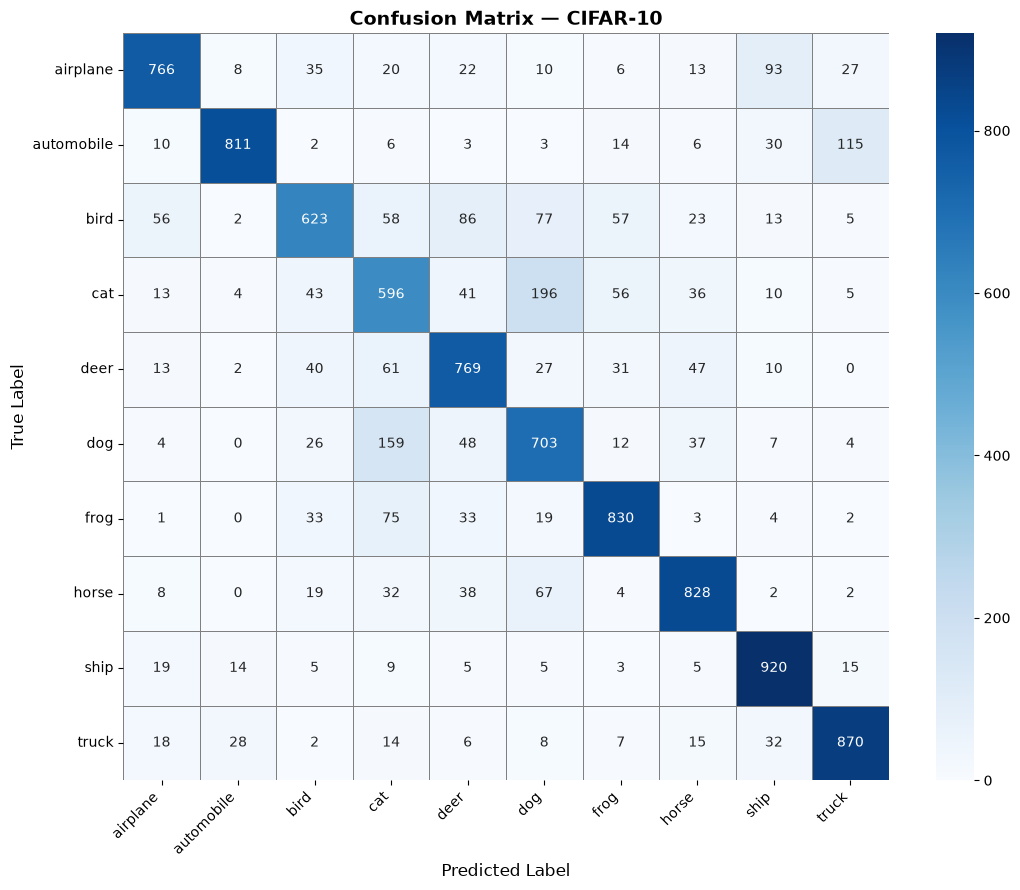

In [44]:
# ─── Confusion Matrix ─────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='grey')
plt.title('Confusion Matrix — CIFAR-10', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
# ─── Classification Report (Precision, Recall, F1) ───────────
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:")
print("=" * 60)
print(report)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.84      0.77      0.80      1000
  automobile       0.93      0.81      0.87      1000
        bird       0.75      0.62      0.68      1000
         cat       0.58      0.60      0.59      1000
        deer       0.73      0.77      0.75      1000
         dog       0.63      0.70      0.66      1000
        frog       0.81      0.83      0.82      1000
       horse       0.82      0.83      0.82      1000
        ship       0.82      0.92      0.87      1000
       truck       0.83      0.87      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000



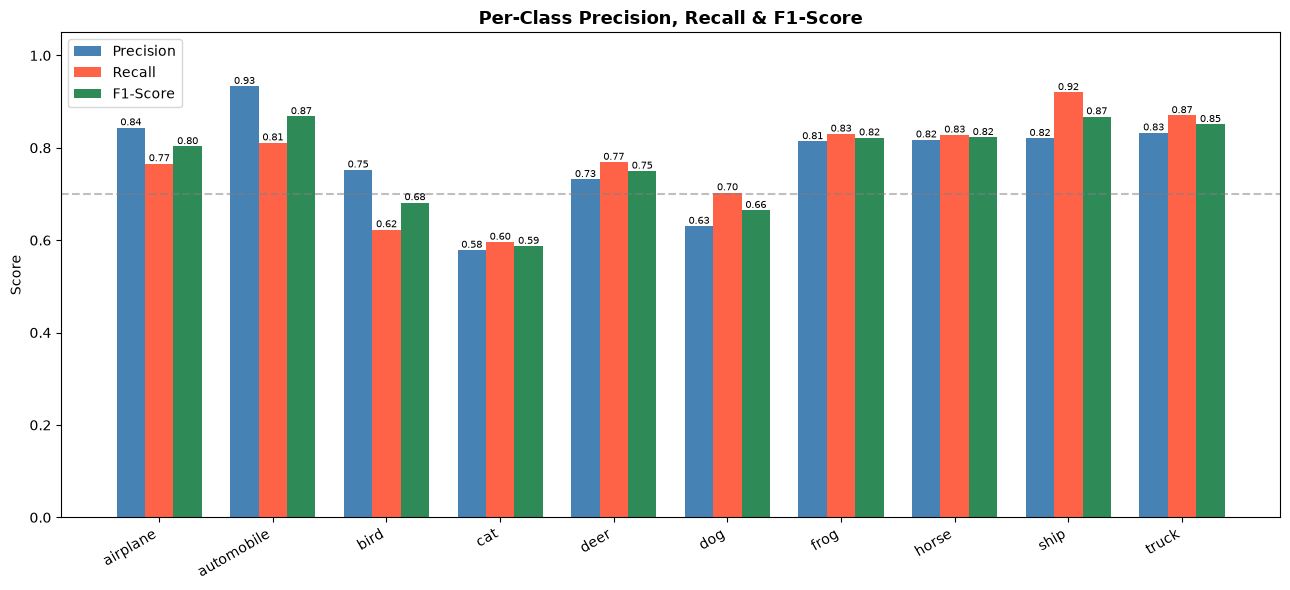


📊 Macro Averages:
   Precision : 0.7754
   Recall    : 0.7716
   F1-Score  : 0.7717

💡 Observation: 'cat' and 'dog' are often confused since they share visual features.


In [46]:
# ─── Per-class Precision & Recall Bar Chart ───────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average=None)
recall    = recall_score(y_true, y_pred, average=None)
f1        = f1_score(y_true, y_pred, average=None)

x_pos = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x_pos - width,      precision, width, label='Precision', color='steelblue')
ax.bar(x_pos,              recall,    width, label='Recall',    color='tomato')
ax.bar(x_pos + width,      f1,        width, label='F1-Score',  color='seagreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall & F1-Score', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=0.7, color='grey', linestyle='--', alpha=0.5, label='0.7 threshold')

# Annotate bars
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=7)

plt.tight_layout(); plt.show()

print(f"\n📊 Macro Averages:")
print(f"   Precision : {precision.mean():.4f}")
print(f"   Recall    : {recall.mean():.4f}")
print(f"   F1-Score  : {f1.mean():.4f}")
print("\n💡 Observation: 'cat' and 'dog' are often confused since they share visual features.")

---
## ✅ Lab Summary

| Task | Description | Key Technique |
|------|------------|---------------|
| 1 | MNIST CNN → 98% accuracy | BatchNorm + Dropout |
| 2 | Wildlife 5-class classification | Filtered CIFAR-10 |
| 3 | Lightweight mobile CNN | SeparableConv2D + GAP |
| 4 | Overfitting prevention | Dropout + Augmentation |
| 5 | Feature map visualization | Intermediate Model output |
| 6 | Save & Load model | model.save() / load_model() |
| 7 | RGB vs Grayscale | Luminance conversion |
| 8 | Optimizer comparison | Adam vs SGD vs RMSprop |
| 9 | Early Stopping | EarlyStopping callback |
| 10 | Evaluation metrics | Confusion Matrix, Precision, Recall, F1 |
